I0000 00:00:1750945601.766129  519757 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1750945601.791665  519902 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1750945601.797575  519901 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1750945601.819069  519903 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


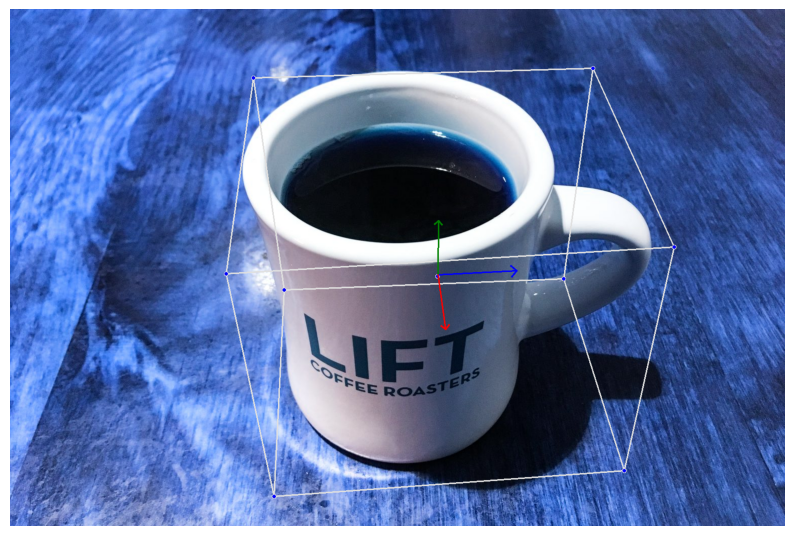

In [1]:
# -------------->  IMPORT LIBRARY
import cv2
import PIL
import urllib
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
mp_objectron = mp.solutions.objectron
mp_drawing = mp.solutions.drawing_utils # helper function

# -----------> 3D OBJECT DETECTION FROM IMAGES GIVEN IN URL

# Define a helper method to fetch images given a URL

def url_to_array(url):
    req = urllib.request.urlopen(url)
    arr = np.array(bytearray(req.read()), dtype=np.int8)
    arr = cv2.imdecode(arr, -1)
    arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
    return arr

# mug = 'https://goodstock.photos/wp-content/uploads/2018/01/Laptop-Coffee-Mug-on-Table.jpg'
mug_image_url ='./Mug.jpg'
# mug = url_to_array(mug_image_url)
mug = cv2.imread('./Mug.jpg')

# ------> LETS INSTANTIATE AN OBJECTRON INSTANCE AND PROCESS() INPUT FUNCTION

objectron = mp_objectron.Objectron(
    static_image_mode=True,
    max_num_objects=5,
    min_detection_confidence=0.2,
    model_name='Cup')

# Inference
results = objectron.process(mug)

#--------------> DISPLAY THE RESULT

if not results.detected_objects:
    print(f'No box landmarks detected.')

# Copy image so as not to draw on the original one
annotated_image = mug.copy()
for detected_object in results.detected_objects:
    # Draw landmarks
    mp_drawing.draw_landmarks(annotated_image,
                              detected_object.landmarks_2d,
                              mp_objectron.BOX_CONNECTIONS)

    # Draw axis based on rotation and translation
    mp_drawing.draw_axis(annotated_image,
                         detected_object.rotation,
                         detected_object.translation)

#-----------> PLOT THE RESULT
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(annotated_image)
ax.axis('off')
plt.show()
